In [1]:
%matplotlib inline

# Mahalanobis distance

Here is an example of the FCM with a different distance metric. I recommend you read on the GK as well.


---

# Mahalanobis Distance

Mahalanobis distance is a distance measure that accounts for the **shape, direction, and spread** of a cluster.
Unlike Euclidean distance, it incorporates the **covariance structure** of the data.

---

## Definition

For a point (x) and cluster center (v) with covariance matrix (\Sigma):

\[
d(x,v) = \sqrt{(x - v)^T \Sigma^j{-1} (x - v)}
\]

Where:

* (\Sigma) = covariance matrix
* (\Sigma^{-1}) = inverse covariance (precision matrix)
* (x - v) = difference vector

---

## Why Mahalanobis Distance Is Needed

Euclidean distance assumes:

* All directions have the same variance
* Features are uncorrelated
* Clusters are spherical

Real clusters often:

* Are elongated
* Are rotated
* Have different spreads in different directions

Mahalanobis distance automatically adjusts for this:

* Movements along **high-variance directions** count as *smaller* distance
* Movements along **low-variance directions** count as *larger* distance
* Correlated features are handled correctly

---

## Geometric Interpretation

Mahalanobis distance defines **elliptical contours** around a center.
Points where (d(x,v) = 1, 2, 3,\ldots) form ellipses aligned with the covariance structure.

These ellipses come from the eigenvalues and eigenvectors of (\Sigma).

---

## Whitening Interpretation

Mahalanobis distance is equivalent to Euclidean distance **after whitening** the data:

* Variances become 1
* Correlations are removed

Formally: whitening transforms the space using (\Sigma^{-1/2}).

---

## Use in Gustafson–Kessel FCM (GK-FCM)

Ordinary FCM uses Euclidean distance and struggles when clusters are:

* Elliptical
* Rotated
* Different sizes

GK-FCM solves this by updating:

* The cluster centers (v_i)
* The cluster covariances (\Sigma_i)

Then it computes membership using Mahalanobis distance.

This allows each cluster to adapt its **own shape and orientation**.

---

## GK Distance Variant

GK-FCM commonly uses this modified distance:

[
B_i = |\Sigma_i|^{1/D} \Sigma_i^{-1}
]

This prevents degeneracy (covariance collapsing to zero) and keeps scaling consistent.

---

## Summary

* Mahalanobis distance accounts for variance and correlation.
* It defines ellipses instead of circles.
* It is essential for clustering algorithms that handle elliptical clusters, such as GK-FCM.

---

If you want, I can also format explanations for:

✔ The covariance update formula
✔ Why (|\Sigma|^{1/D}) appears
✔ How ellipses are drawn from eigenvectors
✔ FCM membership equation

Just tell me!


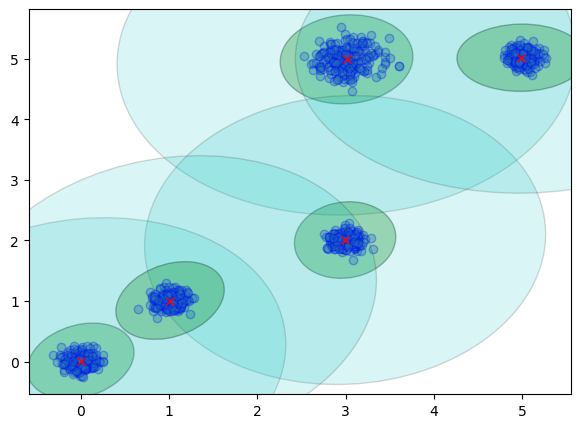

done


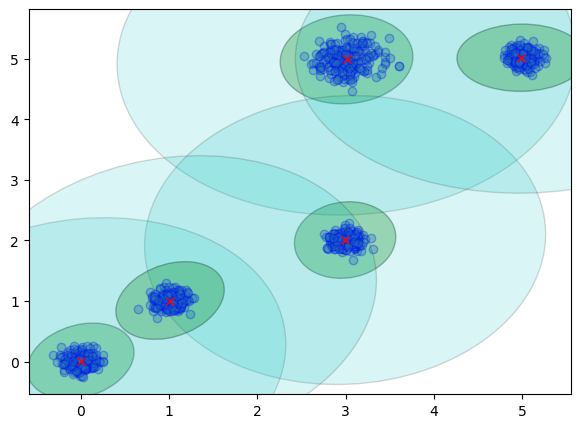

In [2]:
from IPython import display
import pylab as pl
from matplotlib.patches import Ellipse
from sklearn import datasets
import numpy as np
import time
from sklearn import datasets

# import some data to play with
whichone = 0
if( whichone == 0 ):
    samples, labels = datasets.make_blobs(n_samples=1000,
                             centers=[[0.0, 0.0],[1.0, 1.0],[3.0, 2.0],[5.0, 5.0],[3.0,5.0]],
                             cluster_std=[0.1, 0.1, 0.1, 0.1, 0.2],
                             random_state=8)
elif( whichone == 2 ):
    samples, labels = datasets.make_classification(n_samples=500, n_features=2, n_informative=2, 
                    n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1,
                    class_sep=2.5, flip_y=0, weights=[0.5,0.5])   
print( "Shape of data:", samples.shape )
sample_count = samples.shape[0]
feature_count = samples.shape[1]

# lets pick prototype's from the data randomly
cluster_count = 5
Prototypes = np.zeros((cluster_count,feature_count))
for i in range(cluster_count):
    WhichSample = np.random.randint(0, sample_count)
    Prototypes[i,:] = samples[WhichSample,:]
print( "Prototypes start" )
print( Prototypes )

# lets give them identity covariances (The covariance matrix is an identity matrix.)
Covs = np.zeros((cluster_count,feature_count,feature_count)) #  for example, [5,2,2] 5 covariance matrices for 5 classes.

# np.eye() just generates the identity matrix. Them the identity matrix times a random number in [0.1,1.1]
# The initial covariance matrices are all diagonal.(No covariance between features). The variance of features from different clusters are different.
for i in range(cluster_count):
    Covs[i,:,:] = np.eye(feature_count) * (np.random.random() + 0.1) 

print( "First covariance matrix:" )
print( Covs[0,:,:] )

# this is our membership matrix
MembMatrix = np.zeros((sample_count,cluster_count))

# fuzzy factor
M = 1.5

# run that algorithm
T = 100
fig, ax = pl.subplots(nrows = 1, ncols = 1, figsize=(7, 5))

for t in range(T):
                
    pl.clf()   # clear figure
        
    # compute distances 
    sample_prototype_distances_matrix = np.zeros((cluster_count,sample_count))
    for i in range(cluster_count):
        for j in range(sample_count):
            diff = samples[j,:] - Prototypes[i,:]
            A = Covs[i,:,:] + (np.eye(feature_count) * 0.00001) # ensures invertibility
            B = np.linalg.inv(A) * (np.linalg.det(A)**(1/feature_count)) * (1.0**(1/feature_count)) # times a term with determinant to avoid covariance collapse.(Didn't exactly understand)
            calc2 = np.matmul(diff.transpose(),B) # (x−v)' * B    (x−v)' is the transpose of (x-v)
            calc3 = np.matmul(calc2,diff) # (x−v)' * B * (x−v)      matrix multiplication, the result here is a number.  dimension: [1xn][nxn][nx1]
            sample_prototype_distances_matrix[i,j] = np.sqrt( calc3 ) 
            
    # 这里的insex非常混乱，如果自己写要先搞清index
    # update the membership matrix
    # This part is similar to the original FCM. The only diffence is the distance.
    for i in range(cluster_count):
        for n in range(sample_count):
            denominator = 0  
            top = sample_prototype_distances_matrix[i,n]
            for m in range(cluster_count):                
                bottom = sample_prototype_distances_matrix[m,n]
                denominator = denominator + pow(top / (bottom + np.finfo(float).eps) , 1.0/(M-1.0))
            # According to the formula the membership should be 1/denominator. And this value is supposed to be in [0,1], We used this min(max(value, 0.0), 1.0) to avoid numerial issue.(slightly >1 or <0)
            MembMatrix[n,i] = min(max(1.0 / (denominator + np.finfo(float).eps),0.0),1.0)            
    
    # update protos
    for c in range(cluster_count):
        
        # mean
        Top = np.zeros((1,feature_count))
        Bottom = 0        
        for n in range(sample_count):
            Top = Top + ( samples[n,:] * pow(MembMatrix[n,c],M) )
            Bottom = Bottom + pow(MembMatrix[n,c],M)
        Prototypes[c,:] = Top / (Bottom + np.finfo(float).eps)
        
        # cov
        Top = np.zeros((feature_count,feature_count))
        Bottom = 0        
        for n in range(sample_count):
            diff = samples[n,:]-Prototypes[c,:]
            Top = Top + ( np.outer(diff,diff) * pow(MembMatrix[n,c],M) )
            Bottom = Bottom + pow(MembMatrix[n,c],M)
        Covs[c,:,:] = Top / (Bottom + np.finfo(float).eps)        
        
        # drawing time
        
        v, w = np.linalg.eigh( Covs[c,:,:] )
        u = w[0] / np.linalg.norm(w[0])
        anglee = np.arctan2(u[1], u[0])
        anglee = 180 * anglee / np.pi  # convert to degrees
        v = 1. * np.sqrt(2.) * np.sqrt(v)
        ell = Ellipse(Prototypes[c,:], v[0], v[1], angle=180 + anglee, facecolor='r', edgecolor='k', alpha=0.5 )
        pl.gca().add_artist(ell)
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        ell = Ellipse(Prototypes[c,:], v[0], v[1], angle=180 + anglee, facecolor='g', edgecolor='k', alpha=0.3 )
        pl.gca().add_artist(ell)        
        v = 3. * np.sqrt(2.) * np.sqrt(v)
        ell = Ellipse(Prototypes[c,:], v[0], v[1], angle=180 + anglee, facecolor='c', edgecolor='k', alpha=0.15 )
        pl.gca().add_artist(ell) 
        
    # plot    
    X1 = samples[:,0]
    X2 = samples[:,1]
    pl.scatter(X1, X2, edgecolor='b', alpha=0.3 )  
    pl.plot(Prototypes[:,0],Prototypes[:,1],'xr')
        
    # animation, so pause it!
    display.clear_output(wait=True)
    display.display(pl.gcf())
    time.sleep(0.01)    
    
print( "done" )